In [2]:
import os
import jax
from astropy.table import Table
import numpy as np
import jax.numpy as jnp
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from dustmaps.config import config
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
import jax.random as jr
from astropy.io import fits
from hmc_dust.better_hmc import HMCSampler
import jax.scipy.special as jss
import arviz as az
import blackjax
from jax.scipy.stats import t
from jax.scipy.special import logsumexp
from jax.scipy.special import gammaln
from jax.scipy.stats import norm as snorm

from hmc_dust import DATA, GAIA


from pathlib import Path

data_file = Path('../sherlock_results_2/overall_data_Gaia_XP_fitting_actual_data_40345618_combined.npy')
tag = data_file.stem.removeprefix('overall_data_')
# -> 'Gaia_XP_fitting_actual_data_final_run'


INV_GAMMA_MEAN = 9
INV_GAMMA_VAR  = 81
inv_gamma_variance_prior_alpha = INV_GAMMA_MEAN**2/INV_GAMMA_VAR + 2
inv_gamma_variance_prior_beta = INV_GAMMA_MEAN**3/INV_GAMMA_VAR + INV_GAMMA_MEAN
inv_gamma_variance_prior_alpha = jnp.exp(0.1251910775899887)
inv_gamma_variance_prior_beta  = jnp.exp(1.294155478477478)
student_t_sigma = jnp.sqrt(inv_gamma_variance_prior_beta/inv_gamma_variance_prior_alpha)
student_t_nu = 2*inv_gamma_variance_prior_alpha


overall_data_arr = jnp.asarray(np.load(data_file))
accept_prob_arr = jnp.zeros(overall_data_arr[0].size)


RUN = os.environ.get("SLURM_JOB_ID", "local")


def out(name):
    root, ext = os.path.splitext(name)
    return f"{root}_{RUN}{ext}"


fits_table = Table.read(GAIA / "gc_sightline.fits")


gc_builtin = SkyCoord(0*u.deg, 0*u.deg, frame='galactic').icrs


star_coords = SkyCoord(np.asarray(fits_table["ra"])*u.deg, np.asarray(fits_table["dec"])*u.deg)
fits_table["sep_gc_deg"] = star_coords.separation(gc_builtin).deg




plx_np = fits_table["parallax"]              # parallax measurements (mas)
plx = jnp.asarray(np.asarray(plx_np).astype(np.float32))
plx_err_np = fits_table["parallax_err"]         # their uncertainties (mas)
plx_err = jnp.asarray(np.asarray(plx_err_np).astype(np.float32))
ext_np  = fits_table["ext"]                  # extinction
ext = jnp.asarray(np.asarray(ext_np).astype(np.float32))
ext_err_np = fits_table["ext_err"]
ext_err = jnp.asarray(np.asarray(ext_err_np).astype(np.float32))
sep_np = fits_table["sep_gc_deg"]
separation = jnp.asarray(np.asarray(sep_np).astype(np.float32))
print(fits_table.info())


with fits.open(DATA / "mean_and_std_healpix.fits") as hdul:
    hdul.info()
    print(hdul['MEAN'].header['ORDERING'])
    print(hdul['STD.'].header['ORDERING'])
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_along_center = jnp.asarray(hdul["MEAN"].data[:, galactic_center_healpix].astype(np.float32))
    std_along_center  = jnp.asarray(hdul["STD."].data[:, galactic_center_healpix].astype(np.float32))
    radial_centers    = jnp.asarray(hdul["RADIAL PIXEL CENTERS"].data.field(0),    dtype=jnp.float32)
    radial_boundaries = jnp.asarray(hdul["RADIAL PIXEL BOUNDARIES"].data.field(0), dtype=jnp.float32)
    distance_gaps = np.diff(radial_boundaries)


# 1000/x is its own inverse so this fcn is also plx_to_dist
def dist_to_plx(dist):
    return 1000/dist


def get_x_err_basic(plx_err, plx):
    return 1000*(plx**(-2))*plx_err


def logposterior_on_r(r, w, w_err):
    p_w_given_r = -0.5*(w - 1000/r)**2/(w_err**2)
    p_r = distance_logprior(r)
    return p_r + p_w_given_r


def get_x_err_advanced(plx_err, plx):
    x = jnp.linspace(0.1, 100000, 20000)
    log_posterior = logposterior_on_r(x, plx, plx_err)
    y = jnp.exp(log_posterior - jnp.max(log_posterior))
    Z    = jnp.trapezoid(y, x)                    
    mean = jnp.trapezoid(x * y, x) / Z
    var  = jnp.trapezoid((x - mean) ** 2 * y, x) / Z
    return jnp.sqrt(var)


def distance_logprior(r):
    return jnp.where(r > 0, -r/10000 + 2*jnp.log(r), -jnp.inf)








assert mean_along_center.shape == distance_gaps.shape
num_stars = plx.size
distances_psc = dist_to_plx(plx)


linspace = jnp.linspace(0.1, 20000, 500)
x_err_basic = jax.vmap(get_x_err_basic, in_axes=(None, 0))(0.1, 1000/linspace)
x_err_advanced = jax.vmap(get_x_err_advanced, in_axes=(None, 0))(0.1, 1000/linspace)

num_overall_steps = 1100
burn_in = 100
num_dimensions = 600
num_fourier_dimensions = 6000
left_distance_padding = 40
right_distance_padding = 600
doing_burn_in = True
use_NUTS = False
use_blackjax_hmc = False
window_adapt_square_mass_matrix = False



min_distance = radial_boundaries[0] - left_distance_padding
max_distance = radial_boundaries[radial_boundaries.size - 1] + right_distance_padding
dx = (max_distance - min_distance)/(num_dimensions - 1)
integrating_dims_padding_left = 20
integrating_dims_padding_right = 300
total_integrating_dims = integrating_dims_padding_left + integrating_dims_padding_right + num_dimensions
integrating_dust_x_linspace = jnp.arange(num_dimensions + integrating_dims_padding_left + integrating_dims_padding_right)*dx + min_distance - integrating_dims_padding_left*dx
# This is the analouge of fixed_points_linspace
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance

fourier_length = dx*(num_fourier_dimensions - 1)
num_fitting_params = 3
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)
error_bars_on_data = 0.025


cumulative_integrated_dust = jnp.concatenate(
    [jnp.array([0.0]), jnp.cumsum(mean_along_center * distance_gaps)])


x_obs = dist_to_plx(plx)
y_obs = ext




mask = (separation < 0.3) & (plx - plx_err > 1000/1800) & (plx + plx_err < 1000/40)
x_obs = x_obs[mask]
y_obs = y_obs[mask]
plx_obs = plx[mask]
data_ext_err = ext_err[mask]
data_plx_err = plx_err[mask]
x_error = jax.vmap(get_x_err_basic)(plx_err[mask], plx_obs)
num_data = x_obs.size
inv_cov_data_matrix = jnp.linalg.inv(jnp.diag(ext_err[mask]**2))
inv_cov_plx_matrix = jnp.linalg.inv(jnp.diag(plx_err[mask]**2))


initial_logvar = 4.0
initial_lognu = 0
initial_offset = -7.6


logvar_prior_mean = initial_logvar
lognu_prior_mean = 0.0
offset_prior_mean = initial_offset


normalization_factor = num_fourier_dimensions/jnp.sqrt(fourier_length)
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)
fixed_logscale = jnp.log(2*(max_distance - min_distance))
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance
num_good_samples = 5000
time_arr = jnp.arange(num_good_samples)
num_integration_steps = 20000
initial_step_size = 0.00006
step_size = initial_step_size


def hartley(x):
    fft = jnp.fft.fft(x)
    return jnp.real(fft) - jnp.imag(fft)

def logvarprior(logvar):
    return -0.5*(logvar - logvar_prior_mean)**2
def lognuprior(lognu):
    return -0.5*(lognu - lognu_prior_mean)**2
def logoffsetprior(offset):
    return -0.5*(offset - offset_prior_mean)**2

def inv_gamma_logpdf(x, alpha, beta):
    # β^α / Γ(α) * x^(-α-1) * exp(-β/x),  x > 0
    return jnp.where(
        x > 0,
        alpha * jnp.log(beta) - gammaln(alpha) - (alpha + 1.0) * jnp.log(x) - beta / x,
        -jnp.inf,
    )

def cumulative_trapezoid(y, dx):
    seg = dx * (y[:-1] + y[1:]) / 2.0            # area of each trapezoid segment
    return jnp.concatenate([jnp.zeros(1, y.dtype), jnp.cumsum(seg)])

def average_chi_2_based_on_extinction(r, extinction, x_field, y_field, inverse_data_cov):
    def single(r_i, y_field_i):
        model_at_stars = jnp.interp(r_i, x_field, y_field_i)
        residual = extinction - model_at_stars
        return residual.T @ inverse_data_cov @ residual
    return jnp.average(jax.vmap(single, in_axes=(0, 0))(r, y_field))/extinction.size


def average_chi_2_based_on_r(r, plx_obs, inv_plx_cov):
    def single(r_i):
        residual = dist_to_plx(r_i) - plx_obs
        return residual.T @ inv_plx_cov @ residual
    return jnp.average(jax.vmap(single, in_axes = (0,))(r))/plx_obs.size

def exponentiated_integrated_density(logdensity):
    density = jnp.exp(logdensity)
    return cumulative_trapezoid(density, dx)


def response_function(xi, r, inference_params, offset):
    field = fft_field_hartley(xi, inference_params) + offset
    exp_int_field = exponentiated_integrated_density(field)
    return jnp.interp(r, dust_x_linspace, exp_int_field)


def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, lognu = inference_params
        #logvar, lognu = 5.0, jnp.log(0.475)
        logscale = fixed_logscale
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))


def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))


def negative_logdensity(x):
    logvar = x[0]
    lognu = x[1]
    offset = x[2]
    xi = x[3:3 + num_fourier_dimensions]
    r = x[3 + num_fourier_dimensions:]
    # hardcoded r back to fixed values
    #r = x_obs_true
    inference_params = (logvar, lognu)
    # There are priors on everything: logvar, lognu, offset, xi, and r
    negative_log_p_s = -logvarprior(logvar) - lognuprior(lognu) - logoffsetprior(offset) + 0.5*xi.T @ xi - jnp.sum(distance_logprior(r))
    field_res = y_obs - response_function(xi, r, inference_params, offset)
    plx_res = plx_obs - dist_to_plx(r)


    field_t_scores = field_res/ext_err[mask]
    log_data_likelihoods = t.logpdf(field_t_scores, df = student_t_nu, loc = 0.0, scale = student_t_sigma)




    # P(all data given field, params, distance) is now the probability of observing the extinctions (first term) times the probabilty of observing the correct distances (second term)
    negative_log_p_d_given_s = -1*jnp.sum(log_data_likelihoods) + 0.5*plx_res.T @ inv_cov_plx_matrix @ plx_res
    return negative_log_p_s + negative_log_p_d_given_s


def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_dimensions]








An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


<Table length=54602>
     name       dtype 
-------------- -------
gdr3_source_id   int64
            ra float32
           dec float32
      parallax float32
  parallax_err float32
           ext float32
       ext_err float32
        teff_K float32
           feh float32
          logg float32
  plx_over_err float32
    sep_gc_deg float64
None
Filename: /home/dtfrake/hmc-dust/Data_And_Samplers/mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
NEST


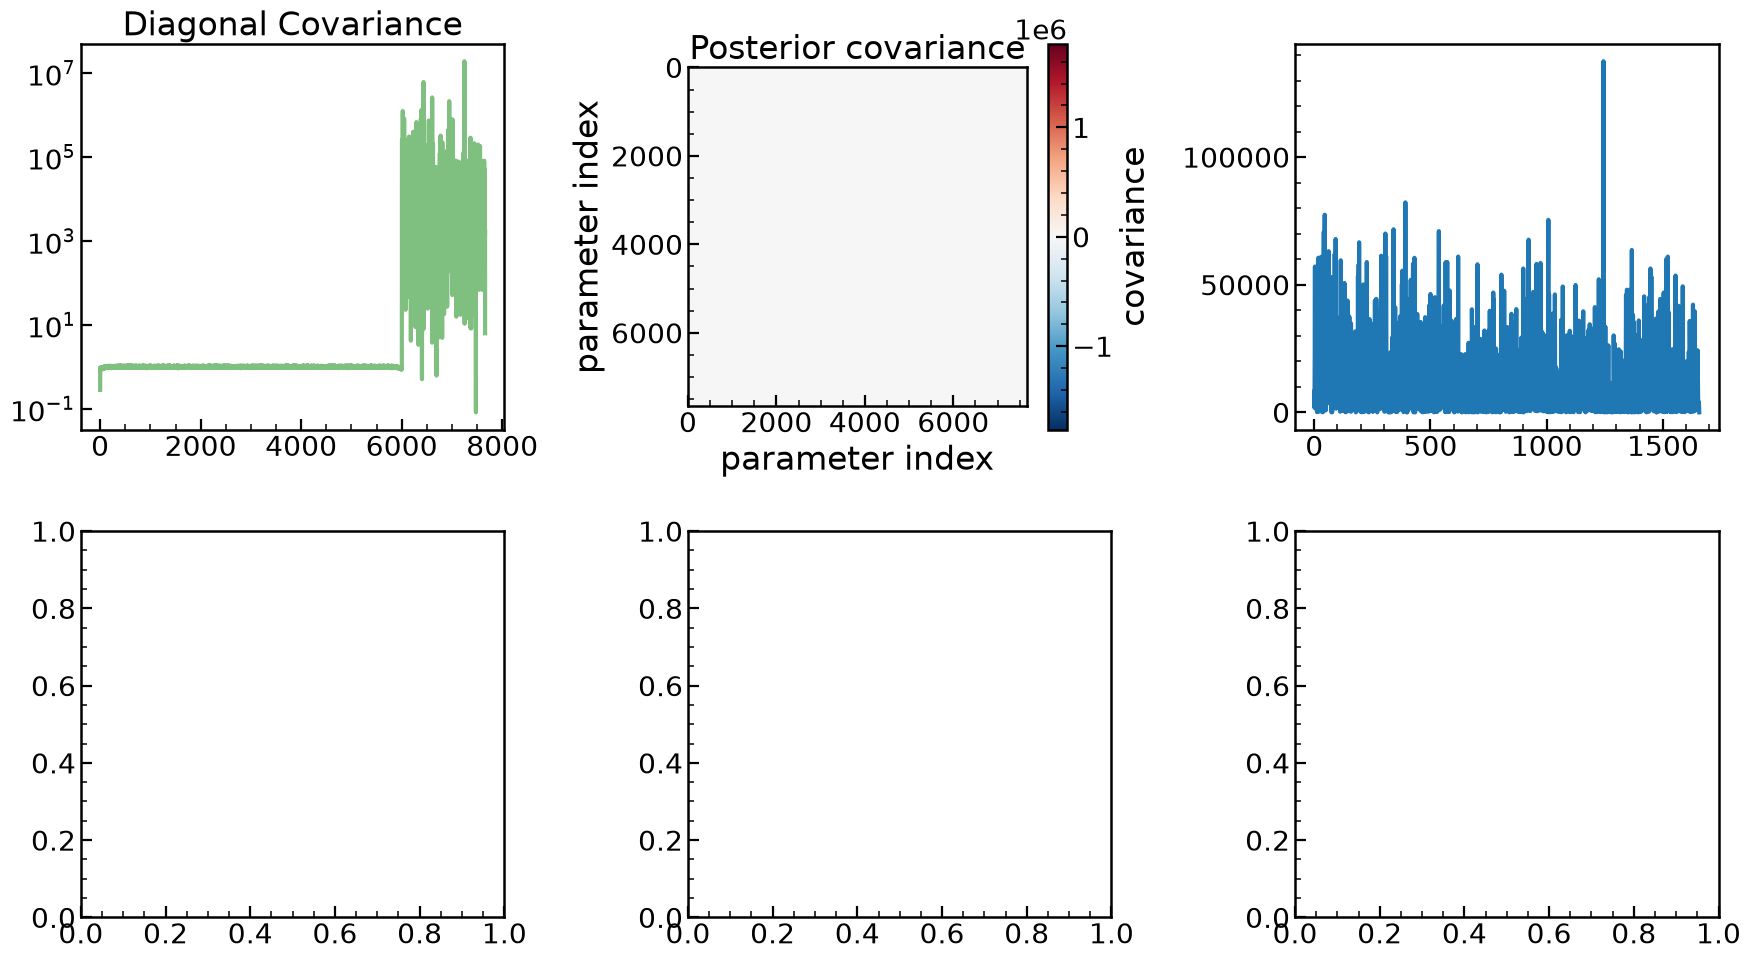

In [3]:
logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
offsets = overall_data_arr[:, 2]
overall_extinction_arr = overall_data_arr[:, 3:3 + num_fourier_dimensions]  
overall_star_location_arr = overall_data_arr[:, 3 + num_fourier_dimensions:]

mean_star_location_arr = overall_star_location_arr.mean(axis=0)
logscales = jnp.zeros_like(logvars)
inference_params = (logvars, lognus)


overall_extinction_arr_raw_before_offsets = jax.vmap(fft_field_hartley, in_axes=(0, 0))(
    overall_extinction_arr, inference_params
)
overall_extinction_arr_raw = overall_extinction_arr_raw_before_offsets + offsets[:, None]
overall_extinction_arr_exp = jax.vmap(exponentiated_integrated_density, in_axes=(0))(
    overall_extinction_arr_raw
)
overall_extinction_arr_raw = overall_extinction_arr_raw[:, 0:num_dimensions]
overall_extinction_arr_exp = overall_extinction_arr_exp[:, 0:num_dimensions]


mean_extinction_raw = overall_extinction_arr_raw.sum(axis=0)/num_good_samples
mean_extinction_exp = jnp.exp(overall_extinction_arr_raw).sum(axis = 0)/num_good_samples
log_mean_extinction_exp = jnp.log(mean_extinction_exp)
mean_extinction_exp_int = overall_extinction_arr_exp.sum(axis=0)/num_good_samples
vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)


errorbar_linspace = jnp.arange(2000)*0.1 + 0.1
def exact_errorbar_loglike(errorbar_mul, ext_true, ext_obs, sigma):
    logprior = inv_gamma_logpdf(errorbar_mul, inv_gamma_variance_prior_alpha, inv_gamma_variance_prior_beta)
    log_p_ext_obs = snorm.logpdf(ext_obs, loc=ext_true, scale=sigma * jnp.sqrt(errorbar_mul))
    return logprior + log_p_ext_obs

def average_errorbar_loglike(errorbar_mul, ext_true_arr, ext_obs, sigma):
    loglike_arr = jax.vmap(exact_errorbar_loglike, in_axes=(None, 0, None, None))(
        errorbar_mul, ext_true_arr, ext_obs, sigma
    )
    return logsumexp(loglike_arr) - jnp.log(ext_true_arr.shape[0])


def exact_position_loglike(index, plx_obs, plx_err, ext_obs, ext_err, field):
    # ext_true is the exponentiated integrated field
    r_exact = integrating_dust_x_linspace[index]
    n = field.shape[0]
    idx = jnp.clip(index - integrating_dims_padding_left, 0, n - 1)
    ext_true = field[idx]
    ext_t_score = (ext_obs - ext_true)/ext_err
    log_ext_likelihood = t.logpdf(ext_t_score, df = student_t_nu, loc = 0.0, scale = student_t_sigma)
    log_x_likelihood = distance_logprior(r_exact) - 0.5*((dist_to_plx(r_exact) - plx_obs)/plx_err)**2
    return log_ext_likelihood + log_x_likelihood




idx = jnp.clip(jnp.arange(total_integrating_dims) - integrating_dims_padding_left,
               0, num_dimensions - 1)
r_grid = integrating_dust_x_linspace[:total_integrating_dims]


# [P, S], sample-independent -- computed once
log_x = (distance_logprior(r_grid)[:, None]
         - 0.5 * ((dist_to_plx(r_grid)[:, None] - plx_obs[None, :]) / data_plx_err[None, :])**2)


@jax.jit
def accumulate(fields):                      # fields: [N_samples, num_dimensions]
    def body(acc, field):
        ext_true = field[idx]                                     # [P]
        tscore = (y_obs[None, :] - ext_true[:, None]) / data_ext_err[None, :]
        ll = t.logpdf(tscore, df=student_t_nu, loc=0.0, scale=student_t_sigma) + log_x
        return jnp.logaddexp(acc, ll), None
    init = jnp.full((total_integrating_dims, y_obs.size), -jnp.inf)
    log_sum, _ = jax.lax.scan(body, init, fields)
    return log_sum - jnp.log(fields.shape[0])


log_mean = accumulate(overall_extinction_arr_exp)




star_posterior_2d = jnp.exp(log_mean)          
dx = integrating_dust_x_linspace[1] - integrating_dust_x_linspace[0]
star_posterior_2d /= (star_posterior_2d.sum(axis=0, keepdims=True) * dx)


x = integrating_dust_x_linspace[:star_posterior_2d.shape[0]]
mean_star_location_arr_analytic = (x @ star_posterior_2d) / star_posterior_2d.sum(axis=0)   # [NUM_STARS]


cov= jnp.cov(overall_data_arr, rowvar = False)


fig, axes = plt.subplots(2, 3, figsize = (18, 10))
timegrid = jnp.arange(num_fourier_dimensions + num_fitting_params + num_data)
axes[0][0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
axes[0][0].set_title("Diagonal Covariance")
axes[0][0].set_yscale("log")
axes[0][2].plot(jnp.arange(data_plx_err.size), x_error**2)
C = np.asarray(cov)
off = C - np.diag(np.diag(C))
vmax = np.abs(off).max()         # symmetric limits so white = 0
im = axes[0][1].imshow(C, cmap='RdBu_r', vmin= -vmax, vmax=vmax)
fig.colorbar(im, ax=axes[0][1], label='covariance')
axes[0][1].set_title('Posterior covariance')
axes[0][1].set_xlabel('parameter index')
axes[0][1].set_ylabel('parameter index')




if use_NUTS or use_blackjax_hmc:
    step_size = parameters['step_size']
    inv_mass_matrix = parameters['inverse_mass_matrix']   # not 'inv_mass_matrix'
    if(window_adapt_square_mass_matrix):
        C = np.asarray(inv_mass_matrix)
        off = C - np.diag(np.diag(C))
        vmax = np.abs(off).max()        
        im = axes[1][0].imshow(jnp.log(C), cmap='RdBu_r', vmin= -vmax, vmax=vmax)
        axes[1][0].colorbar(im, ax=axes[0], label='covariance')
        axes[1][0].set_title('Posterior covariance')
        axes[1][0].set_xlabel('parameter index')
        axes[1][0].set_ylabel('parameter index')
        axes[1][1].plot(jnp.arange(jnp.diagonal(inv_mass_matrix)).size, inv_mass_matrix)
    else :
        axes[1][0].plot(jnp.arange(inv_mass_matrix.size), inv_mass_matrix)


fig.tight_layout()
fig.savefig(f'{tag}_cov_analysis.png', dpi=300, bbox_inches='tight')




In [4]:
def get_avg_errorbar_likelihoods(star_index):
    ext_obs_at_star = y_obs[star_index]
    ext_field_at_star_arr = jax.vmap(jnp.interp, in_axes=(0, None, 0))(
        overall_star_location_arr[:, star_index], dust_x_linspace, overall_extinction_arr_exp
    )
    avg_errorbar_loglikes = jax.vmap(average_errorbar_loglike, in_axes = (0, None, None, None))(errorbar_linspace, ext_field_at_star_arr, ext_obs_at_star, data_ext_err[star_index])
    avg_errorbar_likelihoods = jnp.exp(avg_errorbar_loglikes - jnp.max(avg_errorbar_loglikes))
    return avg_errorbar_likelihoods

def get_mean_errorbar_mul(star_index):
    avg_errorbar_likelihoods = get_avg_errorbar_likelihoods(star_index)
    return jnp.exp(jnp.sum(avg_errorbar_likelihoods*jnp.log(errorbar_linspace))/jnp.sum(avg_errorbar_likelihoods))
mean_errorbars = jax.lax.map(
    get_mean_errorbar_mul,
    jnp.arange(x_obs.size),
    batch_size=2,          # tune this down if you still OOM
)

ESS for Variance parameter (index 0): 1047.556978874834
ESS for Nu parameter (index 1): 1465.398960085275
ESS for First mode:  parameter (index 3): 1852.4764675986712
ESS for Second mode:  parameter (index 4): 1729.2026025400428
ESS for 10th mode  parameter (index 12): 2017.5087592860357
ESS for 100th mode parameter (index 102): 1727.2569217127116
ESS for Last mode parameter (index 6002): 1883.5149466193254
ESS for Star 63 parameter (index 6066): 1147.6237069129606
ESS for Star 105 parameter (index 6108): 1531.7066776792733
Use NUTS? False Use blackjax HMC? False Initial Step Size: 6e-05 Step Size: 6e-05 Num integration steps (only valid if no NUTS) 20000 Burn in: 100
Average acceptance probability (acceptance rate) is: 0.0
Num dimensions: 600 Num data: 1657 Total length: 1819.4813232421875 Noise on each point: 0.025 Num HMC trials: 1100
Error bars on data: 0.025
Logvar prior mean: 4.0 Lognu prior mean: 0.0 Offset prior mean -7.6 Initial logvar/lognu/offset values: 4.0, 0, -7.6
Average

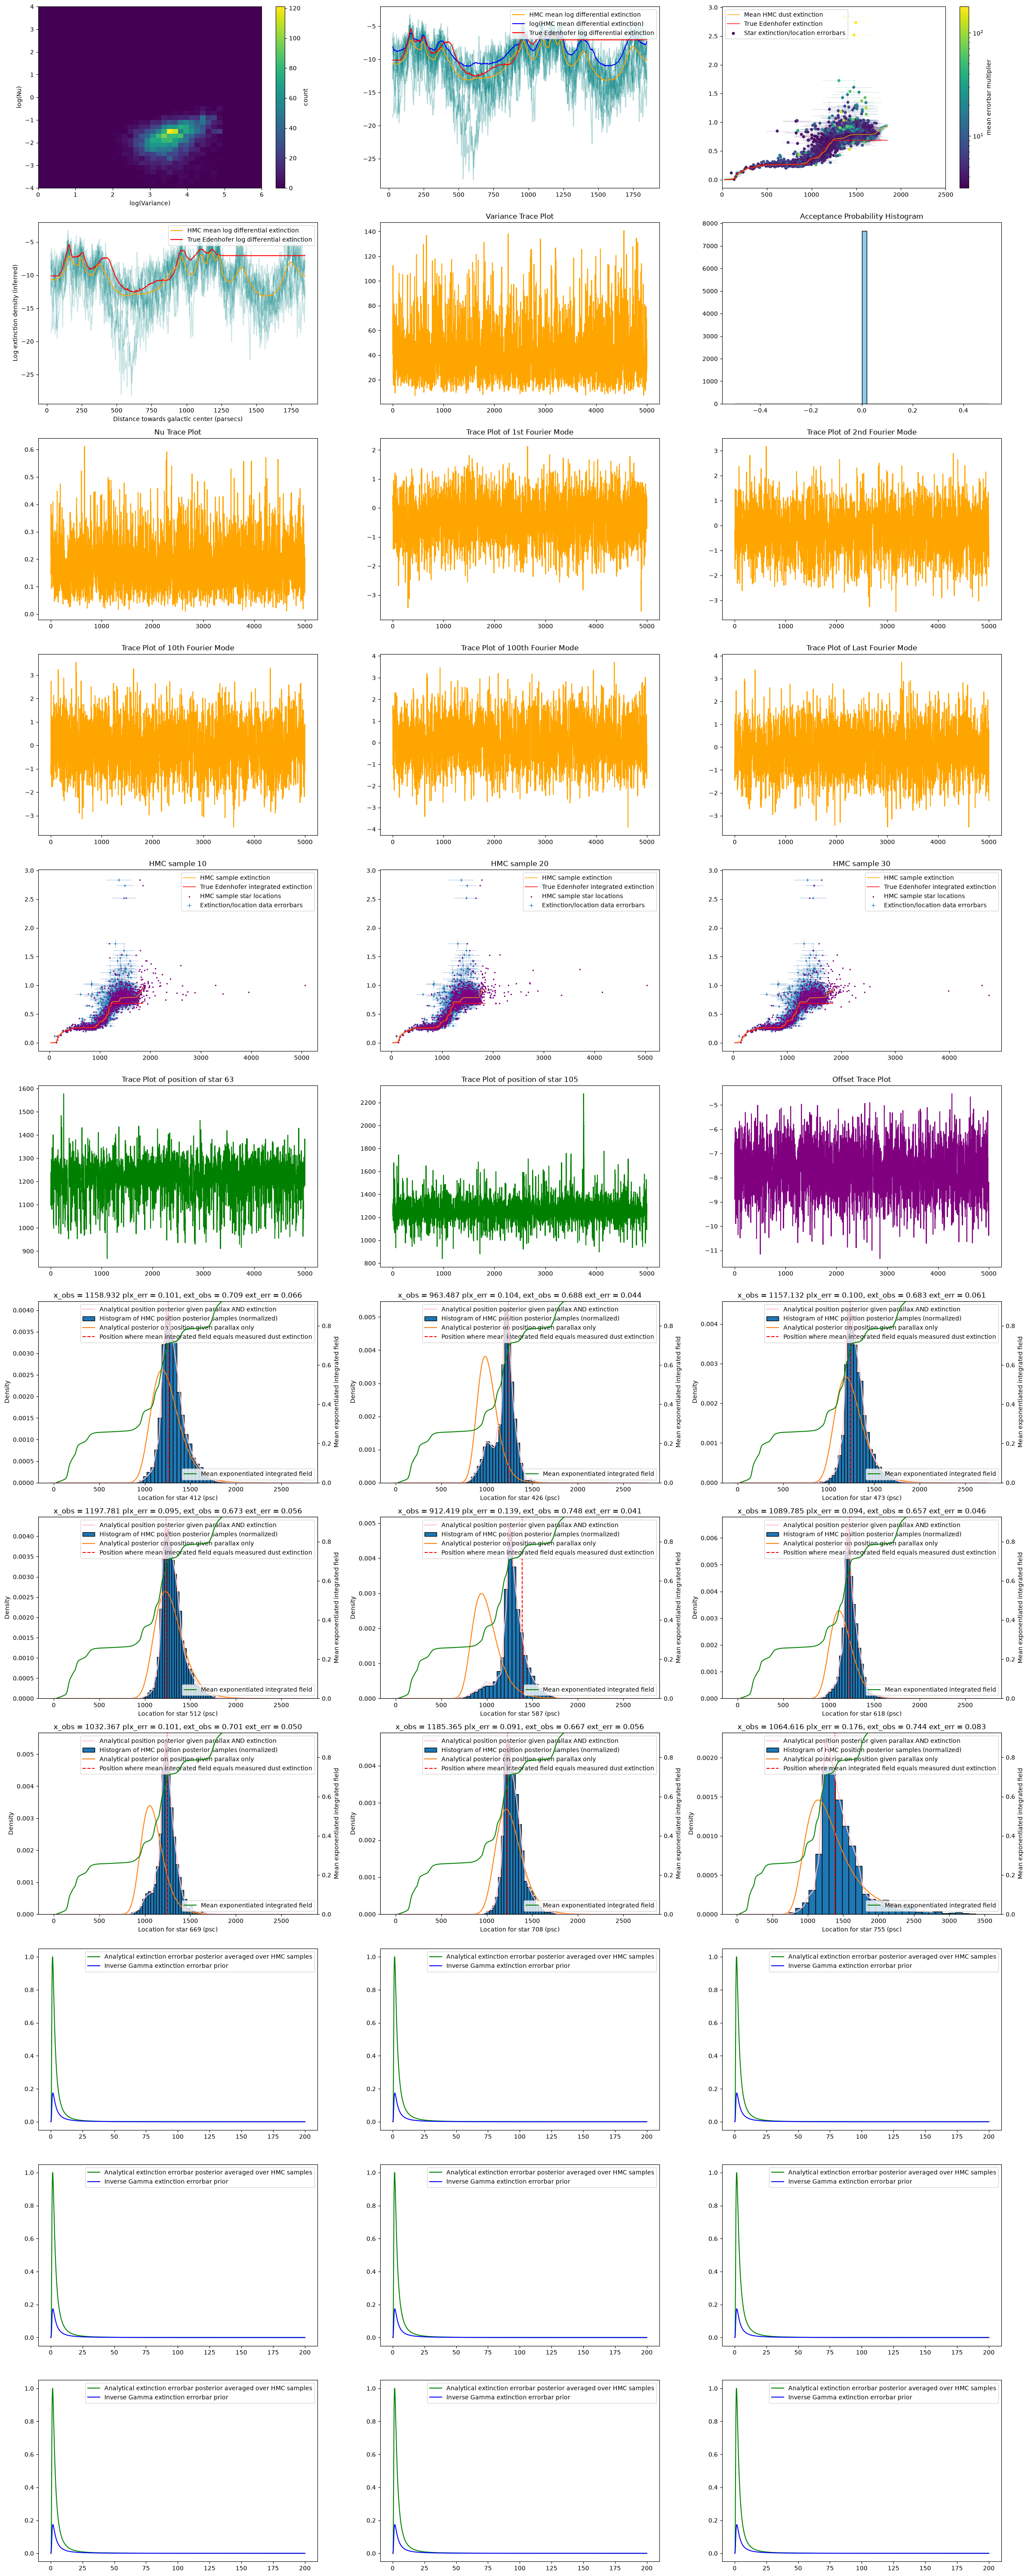

In [5]:
import matplotlib as mpl
from matplotlib.collections import LineCollection
mpl.rcdefaults()
fig, axes = plt.subplots(12, 3, figsize = (24, 60))
star_indices = jnp.arange(num_data)
star_mask = (x_obs < 1200) & (0.65 < y_obs) & (y_obs < 0.75)
star_indices = star_indices[star_mask]
samples_to_highlight = [10, 20, 30]


number_bins_x = 40
number_bins_y = 40
x_min, x_max = -0, 6
y_min, y_max = -4, 4
dx_plot = (x_max - x_min)/number_bins_x
dy_plot = (y_max - y_min)/number_bins_y


x_centers = (jnp.arange(number_bins_x) + 0.5)*dx_plot + x_min
y_centers = (jnp.arange(number_bins_y) + 0.5)*dy_plot + y_min
x_edges = jnp.arange(number_bins_x + 1)*dx_plot + x_min
y_edges = jnp.arange(number_bins_y + 1)*dy_plot + y_min


H_HMC_samples, _, _ = jnp.histogram2d(logvars, lognus, bins=[x_edges, y_edges])


im2 = axes[0][0].imshow(
    H_HMC_samples.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im2, ax=axes[0][0], label='count')
axes[0][0].set_xlabel("log(Variance)")
axes[0][0].set_ylabel("log(Nu)")

for i in range (0, 10):
    axes[0][2].plot(dust_x_linspace, overall_extinction_arr_exp[20*i, :], color = "teal", alpha = 0.3)
    axes[0][1].plot(dust_x_linspace, overall_extinction_arr_raw[20*i, :], color = "teal", alpha = 0.3)


axes[0][1].plot(dust_x_linspace, mean_extinction_raw, color = "orange", alpha = 1, label = "HMC mean log differential extinction")
axes[0][1].plot(dust_x_linspace, log_mean_extinction_exp, color = "blue", alpha = 1, label = "log(HMC mean differential extinction)")
axes[0][1].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)), color = "red", alpha = 1, label = "True Edenhofer log differential extinction")
axes[0][1].legend(loc = "upper right")


axes[0][2].plot(dust_x_linspace, mean_extinction_exp_int, color = "orange", alpha = 0.7, zorder = 45, label = "Mean HMC dust extinction")
axes[0][2].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_boundaries, cumulative_integrated_dust), color = "red", alpha = 0.7, zorder = 50, label = "True Edenhofer extinction")



########################### Claude-Generated color-mapping code BEGINS HERE
ax = axes[0][2]
x = np.asarray(x_obs, dtype=float)
y = np.asarray(y_obs, dtype=float)
c = np.asarray(mean_errorbars, dtype=float)   # jax -> numpy
n_all = x.size

START, END  = 0, 2500                        # <-- selection interval
FILTER_AXIS = 'x'                              # 'x' or 'y'
ERR_ALPHA   = 0.2                              # faint bars
PT_ALPHA    = 1.0                              # solid markers

def _lohi(e, n):
    """(low, high) length-n arrays from a scalar, (n,), or (2, n) error spec."""
    if e is None:
        return None, None
    e = np.asarray(e, dtype=float)
    if e.ndim == 2:                            # asymmetric, shape (2, n)
        return e[0], e[1]
    e = np.broadcast_to(e, (n,))
    return e, e

# broadcast error specs to full length FIRST, so masking keeps them aligned
y_lo, y_hi = _lohi(data_ext_err, n_all)          # vertical bars
x_lo, x_hi = _lohi(x_error, n_all)               # horizontal bars

# --- select on marker position only; bars may extend outside [START, END]
pos  = x if FILTER_AXIS == 'x' else y
keep = (pos >= START) & (pos <= END)
x, y, c = x[keep], y[keep], c[keep]
if y_lo is not None:
    y_lo, y_hi = y_lo[keep], y_hi[keep]
if x_lo is not None:
    x_lo, x_hi = x_lo[keep], x_hi[keep]
n = x.size

positive = c[np.isfinite(c) & (c > 0)]
if n == 0 or positive.size == 0:
    raise ValueError(f"no stars with positive c in {FILTER_AXIS} "
                     f"interval ({START}, {END})")

# --- draw order: low c first, high c (lighter) last so it lands on top.
# non-finite / non-positive values are masked by LogNorm and rendered as
# set_bad, so push them to the very bottom instead of letting argsort
# park the NaNs at the end (i.e. on top).
sort_key = np.where(np.isfinite(c) & (c > 0), c, -np.inf)
order = np.argsort(sort_key, kind='stable')

cmap = plt.get_cmap('viridis').copy()
cmap.set_bad('lightgrey')                      # applies to scatter + bars too
# color scale spans only the shown stars; use the unmasked c for a fixed
# scale shared across panels
impostor_norm = mpl.colors.LogNorm(vmin=positive.min(), vmax=positive.max())

xs, ys, cs = x[order], y[order], c[order]
colors = cmap(impostor_norm(cs))
if y_lo is not None:
    y_lo, y_hi = y_lo[order], y_hi[order]
if x_lo is not None:
    x_lo, x_hi = x_lo[order], x_hi[order]

# interleave per point, so a whole point's cross is painted before the next
segs, seg_colors = [], []
for i in range(n):
    if y_lo is not None:
        segs.append([(xs[i], ys[i] - y_lo[i]), (xs[i], ys[i] + y_hi[i])])
        seg_colors.append(colors[i])
    if x_lo is not None:
        segs.append([(xs[i] - x_lo[i], ys[i]), (xs[i] + x_hi[i], ys[i])])
        seg_colors.append(colors[i])

if segs:
    ax.add_collection(LineCollection(segs, colors=np.asarray(seg_colors),
                                     linewidths=0.8, alpha=ERR_ALPHA,
                                     capstyle='butt', zorder=2))

ax.scatter(xs, ys, c=cs, cmap=cmap, norm=impostor_norm, s=4**2, alpha=PT_ALPHA,
           zorder=3, label="Star extinction/location errorbars")
ax.autoscale_view()

cb = fig.colorbar(mpl.cm.ScalarMappable(norm=impostor_norm, cmap=cmap), ax=ax)
cb.set_label("mean errorbar multiplier")
#################################  Claude-Generated color-mapping code ENDS HERE




#axes[0][2].scatter(mean_star_location_arr, y_obs, color = "purple", s = 2, zorder = 10, label = "Mean HMC star locations")
axes[0][2].set_xlim(START, END)
axes[0][2].legend(loc = "upper left")


axes[1][0].set_ylabel("Log extinction density (inferred)")
axes[1][0].set_xlabel("Distance towards galactic center (parsecs)")
axes[1][0].plot(dust_x_linspace, mean_extinction_raw, color = "orange", alpha = 1, zorder = 10, label = "HMC mean log differential extinction")

indices_plot_10 = np.array([20*i for i in range(10)])
for k, i in enumerate(range(indices_plot_10.size)):
    axes[1][0].plot(dust_x_linspace, overall_extinction_arr_raw[indices_plot_10[i], :], color = "teal", alpha=0.2,)


axes[1][0].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)), color = "red", alpha = 1, label = "True Edenhofer log differential extinction")
axes[1][0].legend(loc = "upper right")


axes[1][1].plot(time_arr, vars, color = "Orange")
axes[1][1].set_title("Variance Trace Plot")


axes[1][2].set_title("Acceptance Probability Histogram")
axes[1][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')


axes[2][0].plot(time_arr, nus, color = "Orange")
axes[2][0].set_title("Nu Trace Plot")


axes[2][1].plot(time_arr, overall_extinction_arr[:, 0], color = "Orange")
axes[2][1].set_title("Trace Plot of 1st Fourier Mode")


axes[2][2].plot(time_arr, overall_extinction_arr[:, 1], color = "Orange")
axes[2][2].set_title("Trace Plot of 2nd Fourier Mode")

axes[3][0].plot(time_arr, overall_extinction_arr[:, 9], color = "Orange")
axes[3][0].set_title("Trace Plot of 10th Fourier Mode")

axes[3][1].plot(time_arr, overall_extinction_arr[:, 99], color = "Orange")
axes[3][1].set_title("Trace Plot of 100th Fourier Mode")


axes[3][2].plot(time_arr, overall_extinction_arr[:, num_fourier_dimensions - 1], color = "Orange")
axes[3][2].set_title("Trace Plot of Last Fourier Mode")



for i in range (0, 3):
    axes[4][i].plot(dust_x_linspace, overall_extinction_arr_exp[samples_to_highlight[i], :], color = 'orange', alpha = 0.7, zorder = 10, label = "HMC sample extinction")
    axes[4][i].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_boundaries, cumulative_integrated_dust), color = "red", alpha = 0.7, zorder = 20, label = "True Edenhofer integrated extinction")
    axes[4][i].errorbar(x_obs, y_obs, yerr = data_ext_err, xerr = x_error, fmt='.', markersize=4, ecolor='#9ab8d8', elinewidth=0.8, capsize=0, alpha=0.8, zorder = 1, label = "Extinction/location data errorbars")
    axes[4][i].scatter(overall_star_location_arr[samples_to_highlight[i], :], y_obs, color = "purple", s = 2, zorder = 3, label = "HMC sample star locations")
    axes[4][i].set_title(f"HMC sample {samples_to_highlight[i]}")
    axes[4][i].legend(loc = "upper right")
    max_v = float(jnp.max(mean_extinction_exp_int))
    for j in range (0, 3):
        ax = axes[6 + j][i]
        lower_ax = axes[9 + j][i]
        star_index = star_indices[i + 3*j + 9]
        avg_errorbar_likelihoods = get_avg_errorbar_likelihoods(star_index)
        prior_loglikes = inv_gamma_logpdf(errorbar_linspace, inv_gamma_variance_prior_alpha, inv_gamma_variance_prior_beta)
        prior_loglikes = jnp.exp(prior_loglikes)
        lower_ax.plot(errorbar_linspace, avg_errorbar_likelihoods, color = "green", label = "Analytical extinction errorbar posterior averaged over HMC samples")
        lower_ax.plot(errorbar_linspace, prior_loglikes, color = "blue", label = "Inverse Gamma extinction errorbar prior")
        lower_ax.legend(loc = "upper right")

        ax.plot(integrating_dust_x_linspace, star_posterior_2d[:, star_index], color = "pink", zorder = 100, label = "Analytical position posterior given parallax AND extinction")
        ax.hist(overall_star_location_arr[:, star_index], bins=30, edgecolor="black", density=True, label="Histogram of HMC position posterior samples (normalized)")
        ax.set_xlabel(f"Location for star {star_index} (psc)")
        ax.set_ylabel("Density")
        star_linspace = jnp.linspace(min_distance, max_distance + 500, num_dimensions)
        log_r_posterior = logposterior_on_r(star_linspace, plx_obs[star_index], data_plx_err[star_index])
        r_posterior = jnp.exp(log_r_posterior - jnp.max(log_r_posterior))
        r_posterior = (r_posterior/jnp.sum(r_posterior))*num_dimensions/(max_distance + 500 - min_distance)
        ax.plot(star_linspace, r_posterior, label="Analytical posterior on position given parallax only")
        ax.axvline(x=jnp.interp(y_obs[star_index], mean_extinction_exp_int, dust_x_linspace),
                   color="red", linestyle="--",
                   label="Position where mean integrated field equals measured dust extinction")
        ax.set_title(f"x_obs = {x_obs[star_index]:.3f} plx_err = {data_plx_err[star_index]:.3f}, ext_obs = {y_obs[star_index]:.3f} ext_err = {data_ext_err[star_index]:.3f}")


        ax2 = ax.twinx()
        ax2.plot(dust_x_linspace, mean_extinction_exp_int, color="green",
                 label="Mean exponentiated integrated field")
        ax2.set_ylim(0, max_v)                          # identical across all nine plots
        ax2.set_ylabel("Mean exponentiated integrated field")
        ax.legend(loc = "upper right")
        ax2.legend(loc = "lower right")


axes[5][0].plot(time_arr, overall_star_location_arr[:, star_indices[0]], color = "Green")
axes[5][0].set_title(f"Trace Plot of position of star {star_indices[0]}")


axes[5][1].plot(time_arr, overall_star_location_arr[:, star_indices[1]], color = "Green")
axes[5][1].set_title(f"Trace Plot of position of star {star_indices[1]}")


axes[5][2].plot(time_arr, offsets, color = "Purple")
axes[5][2].set_title("Offset Trace Plot")


fig.tight_layout()

fig.savefig(f'{tag}_plots_analysis.png', dpi=100)

posterior_samples = overall_data_arr[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)
idata = az.from_dict({"posterior": {"theta": posterior_samples}})
ess_param_index = 30  
az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [ess_param_index]})


ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once
indices_of_interest = {"Variance": 0, "Nu": 1, "First mode: ": num_fitting_params, "Second mode: ": num_fitting_params + 1, "10th mode ": num_fitting_params + 9, "100th mode": num_fitting_params + 99, 
                       "Last mode": num_fourier_dimensions + num_fitting_params - 1,  f"Star {star_indices[0]}": star_indices[0] + num_fitting_params + num_fourier_dimensions, f"Star {star_indices[1]}": star_indices[1] + num_fitting_params + num_fourier_dimensions}
for label, idx in indices_of_interest.items():
    ess_val = ess_all["theta"].sel(theta_dim_0=idx).values
    print(f"ESS for {label} parameter (index {idx}): {ess_val}")


print(f"Use NUTS? {use_NUTS} Use blackjax HMC? {use_blackjax_hmc} Initial Step Size: {initial_step_size} Step Size: {step_size} Num integration steps (only valid if no NUTS) {num_integration_steps} Burn in: {burn_in}")
print(f"Average acceptance probability (acceptance rate) is: {jnp.average(accept_prob_arr)}")
print(f"Num dimensions: {num_dimensions} Num data: {num_data} Total length: {max_distance - min_distance} Noise on each point: {error_bars_on_data} Num HMC trials: {num_overall_steps}")
prior_variances = jnp.diag(cov)[3:3 + num_fourier_dimensions]
print(f"Error bars on data: {error_bars_on_data}")
print(f"Logvar prior mean: {logvar_prior_mean} Lognu prior mean: {lognu_prior_mean} Offset prior mean {offset_prior_mean} Initial logvar/lognu/offset values: {initial_logvar}, {initial_lognu}, {initial_offset}")
print(f"Average chi_2 statistic based on the prior: {jnp.average(prior_variances)}")  
print(f"Average chi_2 statistic based on the extinction per star: {average_chi_2_based_on_extinction(overall_star_location_arr, y_obs, dust_x_linspace, overall_extinction_arr_exp, inv_cov_data_matrix)}")
print(f"Average chi_2 statistic based on the distance/parallax per star: {average_chi_2_based_on_r(overall_star_location_arr, plx_obs, inv_cov_plx_matrix)}")

plt.close()


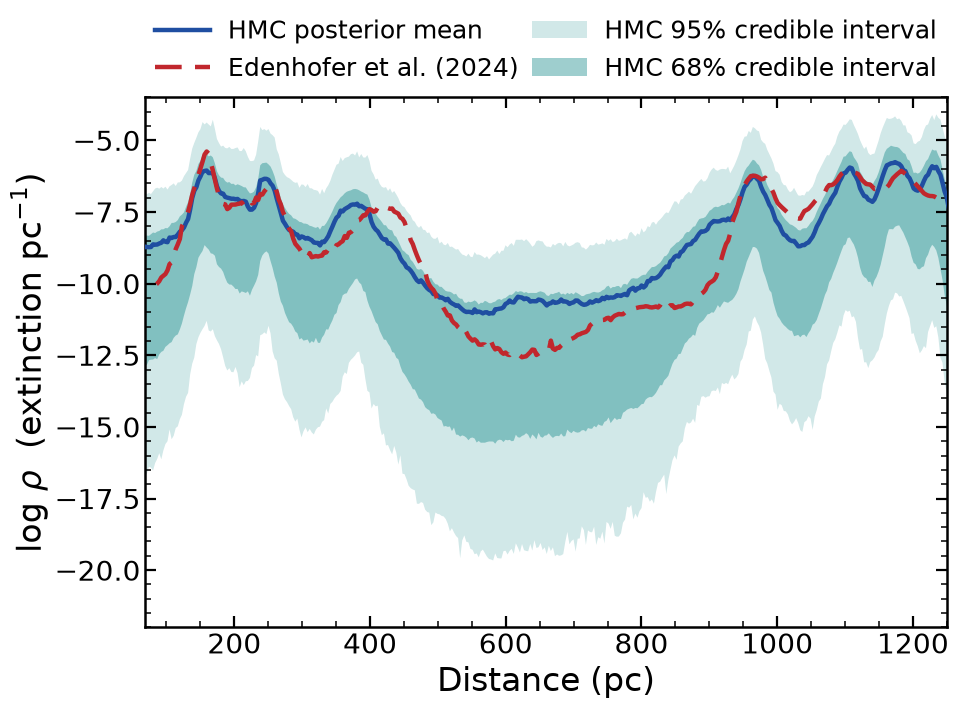

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

# ---------- poster styling ----------
mpl.rcParams.update({
    "figure.figsize": (10, 7.5), "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 20, "axes.labelsize": 24, "legend.fontsize": 18,
    "xtick.labelsize": 20, "ytick.labelsize": 20,
    "axes.linewidth": 1.8, "lines.linewidth": 3.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.size": 8, "ytick.major.size": 8,
    "xtick.minor.size": 4, "ytick.minor.size": 4,
    "xtick.major.width": 1.6, "ytick.major.width": 1.6,
    "xtick.minor.width": 1.1, "ytick.minor.width": 1.1,
})

fig, ax = plt.subplots()

# ---------- posterior band ----------
samples = np.asarray(overall_extinction_arr_raw)          # (n_samples, n_dist)
lo95, lo68, hi68, hi95 = np.percentile(samples, [2.5, 16, 84, 97.5], axis=0)

ax.fill_between(dust_x_linspace, lo95, hi95, color="teal", alpha=0.18, lw=0,
                label="HMC 95% credible interval")
ax.fill_between(dust_x_linspace, lo68, hi68, color="teal", alpha=0.38, lw=0,
                label="HMC 68% credible interval")

# ---------- curves ----------
ax.plot(dust_x_linspace, log_mean_extinction_exp,
        color="#1f4ea1", lw=3.2, zorder=3, label="HMC posterior mean")
ax.plot(dust_x_linspace,
        jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)),
        color="#c1272d", lw=3.2, ls="--", dashes=(6, 3), zorder=4,
        label="Edenhofer et al. (2024)")

# ---------- axes ----------
ax.set_xlim(69, 1250)
ax.set_ylim(-22, -3.5)                    # crop the unconstrained lower tail
ax.set_xlabel("Distance (pc)")
ax.set_ylabel(r"$\log\,\rho$  (extinction pc$^{-1}$)")

# ---------- legend above the axes, two columns ----------
h, l = ax.get_legend_handles_labels()
order = [2, 3, 0, 1]                      # curves in left column, bands in right
ax.legend([h[i] for i in order], [l[i] for i in order],
          loc="lower left", bbox_to_anchor=(0.0, 1.01, 1.0, 0.2),
          mode="expand", ncol=2, frameon=False,
          handlelength=2.2, columnspacing=1.6, handletextpad=0.7,
          borderaxespad=0.0)

fig.tight_layout()
fig.savefig("extinction_profile.pdf")
fig.savefig("extinction_profile.png")     # for slides / quick looks
plt.show()

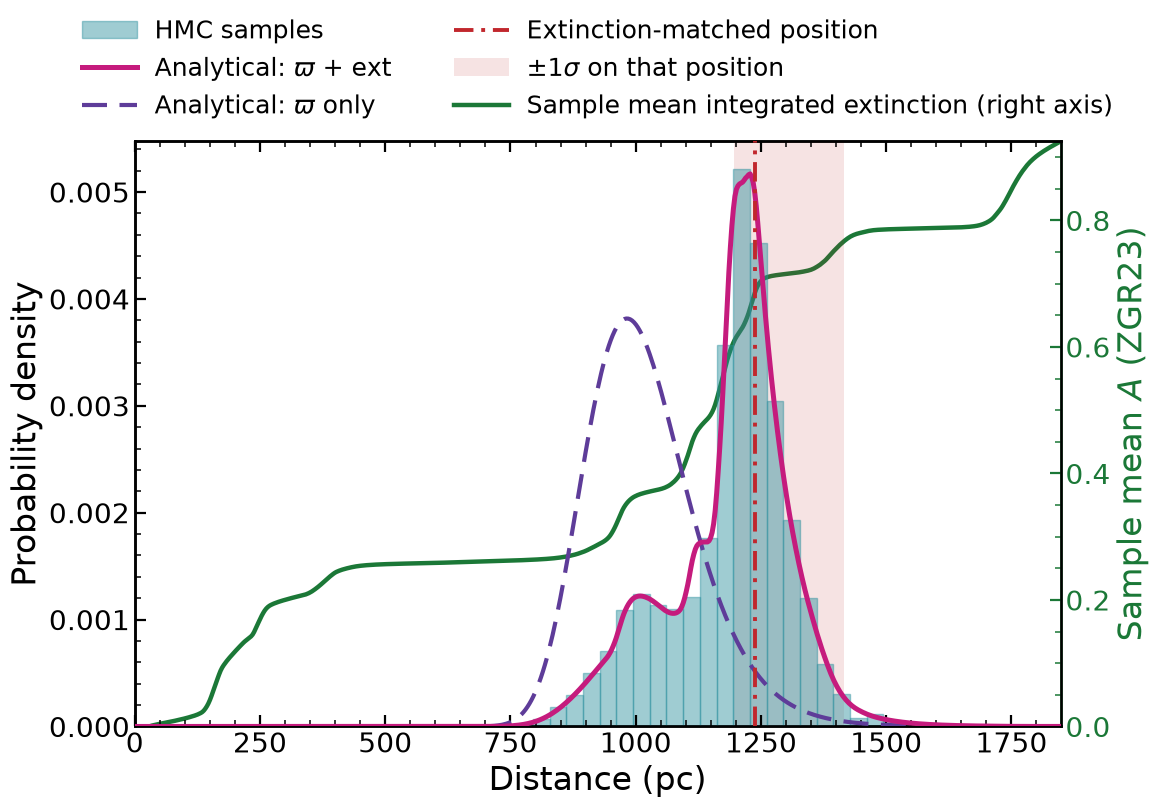

In [7]:

import matplotlib as mpl
import matplotlib.pyplot as plt
import jax.numpy as jnp

# ---------- poster styling ----------
mpl.rcParams.update({
    "figure.figsize": (12, 8.5), "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 20, "axes.labelsize": 24, "legend.fontsize": 18,
    "xtick.labelsize": 20, "ytick.labelsize": 20,
    "axes.linewidth": 1.8, "lines.linewidth": 3.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.size": 8, "ytick.major.size": 8,
    "xtick.minor.size": 4, "ytick.minor.size": 4,
    "xtick.major.width": 1.6, "ytick.major.width": 1.6,
    "xtick.minor.width": 1.1, "ytick.minor.width": 1.1,
})

C_HMC   = "#2a8f9d"   # teal, matches the extinction-profile panel
C_BOTH  = "#c51b7d"   # analytical, parallax + extinction
C_PLX   = "#5e3c99"   # analytical, parallax only
C_MATCH = "#c1272d"   # extinction-matched position
C_FIELD = "#1b7837"   # right-axis field

fig, ax = plt.subplots(1, 1)

star_index = star_indices[10]

# ---------- extinction-matched position and its 1-sigma span ----------
x_match = jnp.interp(y_obs[star_index], mean_extinction_exp_int, dust_x_linspace)
x_minus = jnp.interp(y_obs[star_index] - data_ext_err[star_index]*student_t_sigma,
                     mean_extinction_exp_int, dust_x_linspace)
x_plus  = jnp.interp(y_obs[star_index] + data_ext_err[star_index]*student_t_sigma,
                     mean_extinction_exp_int, dust_x_linspace)

ax.axvspan(x_minus, x_plus, color=C_MATCH, alpha=0.13, lw=0, zorder=0,
           label=r"$\pm 1\sigma$ on that position")

# ---------- HMC samples ----------
ax.hist(overall_star_location_arr[:, star_index], bins=30, density=True,
        color=C_HMC, alpha=0.45, edgecolor=C_HMC, linewidth=1.0, zorder=1,
        label="HMC samples")

# ---------- analytical posteriors ----------
ax.plot(integrating_dust_x_linspace, star_posterior_2d[:, star_index],
        color=C_BOTH, lw=3.6, zorder=5,
        label=r"Analytical: $\varpi$ + ext")

star_linspace = jnp.linspace(min_distance, max_distance + 500, num_dimensions)
log_r_posterior = logposterior_on_r(star_linspace, plx_obs[star_index], data_plx_err[star_index])
r_posterior = jnp.exp(log_r_posterior - jnp.max(log_r_posterior))
r_posterior = (r_posterior / jnp.sum(r_posterior)) * num_dimensions / (max_distance + 500 - min_distance)
ax.plot(star_linspace, r_posterior, color=C_PLX, lw=3.0, ls="--", dashes=(6, 3),
        zorder=4, label=r"Analytical: $\varpi$ only")

ax.axvline(x=x_match, color=C_MATCH, lw=2.8, ls=(0, (5, 2, 1, 2)), zorder=6,
           label="Extinction-matched position")

ax.set_xlabel("Distance (pc)")
ax.set_ylabel("Probability density")
ax.tick_params(right=False)            # right spine belongs to ax2
ax.set_ylim(bottom=0)

# ---------- right axis: integrated field ----------
ax2 = ax.twinx()
ax2.plot(dust_x_linspace, mean_extinction_exp_int, color=C_FIELD, lw=3.2,
         label="Sample mean integrated extinction (right axis)")
ax2.set_ylim(0, max_v)
ax2.set_ylabel(r"$\mathrm{Sample\ mean}\  A\ (\mathrm{ZGR23})$", color=C_FIELD)
ax2.tick_params(axis="y", colors=C_FIELD, which="both")
ax2.spines["right"].set_color(C_FIELD)
ax2.spines["right"].set_linewidth(1.8)

# let the left-axis artists draw above the green line
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

ax.set_xlim(0, max_distance)
ax2.set_xlim(0, max_distance)
# ---------- one combined legend, above the axes, sized to its text ----------
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
h, l = h1 + h2, l1 + l2
order = [1, 2, 3, 4, 0, 5]   # left col: HMC, both, plx-only | right col: line, band, field
ax.legend([h[i] for i in order], [l[i] for i in order],
          loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=2, frameon=False,
          handlelength=2.2, columnspacing=2.5, handletextpad=0.7,
          labelspacing=0.5, borderaxespad=0.0)

fig.tight_layout()
fig.savefig(f"star_{star_index}_position_posterior.pdf")
fig.savefig(f"star_{star_index}_position_posterior.png")
plt.show()

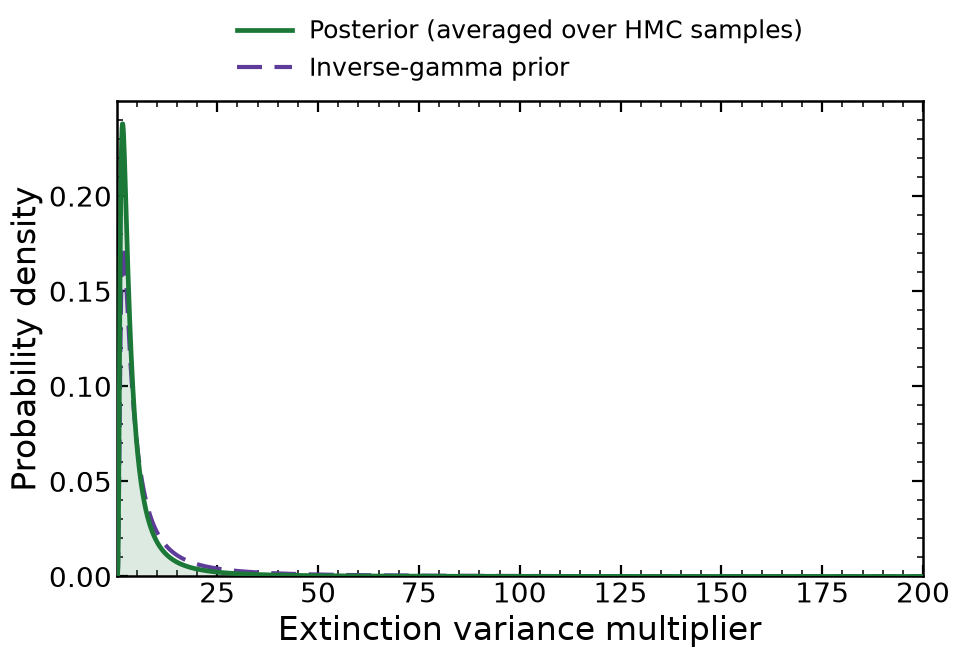

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import jax.numpy as jnp

# ---------- poster styling ----------
mpl.rcParams.update({
    "figure.figsize": (10, 7), "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 20, "axes.labelsize": 24, "legend.fontsize": 18,
    "xtick.labelsize": 20, "ytick.labelsize": 20,
    "axes.linewidth": 1.8, "lines.linewidth": 3.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.size": 8, "ytick.major.size": 8,
    "xtick.minor.size": 4, "ytick.minor.size": 4,
    "xtick.major.width": 1.6, "ytick.major.width": 1.6,
    "xtick.minor.width": 1.1, "ytick.minor.width": 1.1,
})

C_POST  = "#1b7837"   # posterior, green (matches the field colour)
C_PRIOR = "#5e3c99"   # prior, purple (matches "parallax only")
C_TRUE  = "#c1272d"   # measured value

fig, ax = plt.subplots(1, 1)

star_index = star_indices[4]

# ---------- posterior, normalised to a proper density ----------
dx = errorbar_linspace[1] - errorbar_linspace[0]
avg_errorbar_likelihoods = get_avg_errorbar_likelihoods(star_index)
post_density = avg_errorbar_likelihoods / (jnp.sum(avg_errorbar_likelihoods) * dx)

# ---------- prior ----------
prior_density = jnp.exp(inv_gamma_logpdf(errorbar_linspace,
                                         inv_gamma_variance_prior_alpha,
                                         inv_gamma_variance_prior_beta))

ax.fill_between(errorbar_linspace, post_density, color=C_POST, alpha=0.15, lw=0, zorder=2)
ax.plot(errorbar_linspace, post_density, color=C_POST, lw=3.4, zorder=5,
        label="Posterior (averaged over HMC samples)")

ax.plot(errorbar_linspace, prior_density, color=C_PRIOR, lw=3.0, ls="--", dashes=(6, 3),
        zorder=4, label="Inverse-gamma prior")

ax.set_xlabel("Extinction variance multiplier")
ax.set_ylabel("Probability density")
ax.set_ylim(bottom=0)
ax.set_xlim(errorbar_linspace[0], errorbar_linspace[-1])

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=1, frameon=False,
          handlelength=2.2, handletextpad=0.7, labelspacing=0.5, borderaxespad=0.0)

fig.tight_layout()
fig.savefig(f"star_{star_index}_errorbar_posterior.pdf")
fig.savefig(f"star_{star_index}_errorbar_posterior.png")
plt.show()

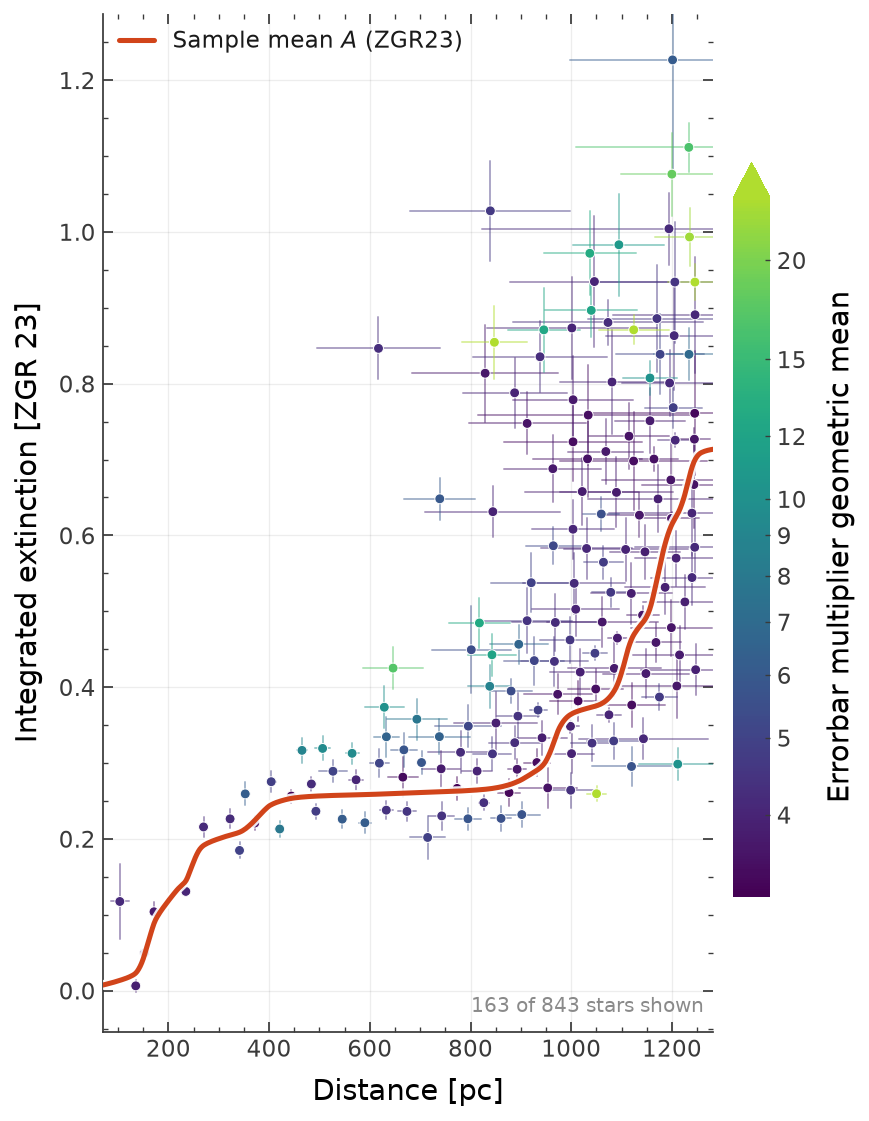

In [9]:
import numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
 
# ---------------------------------------------------------------- knobs
START, END   = 67, 1250      # selection interval
FILTER_AXIS  = 'x'          # 'x' or 'y'
MIN_SEP_IN   = 0.155        # min marker spacing, INCHES on the page. lower = more stars
TARGET_N     = None         # or an int: solves MIN_SEP_IN for you, overrides it
MARKER_SIZE  = 26           # points^2
ERR_ALPHA    = 0.45
FIGSIZE      = (6.4, 8.2)
CLIP_PCT     = 98           # colorbar saturates here; None = use the true max
CBAR_MAX_TICKS = 14         # tick budget; raise for an even denser colorbar
XLABEL, YLABEL = "Distance [pc]", "Integrated extinction [ZGR 23]"
CBAR_LABEL   = "Errorbar multiplier geometric mean"
CURVE_LABEL = r"$\mathrm{Sample\ mean}\  A\ (\mathrm{ZGR23})$"
CURVE_COLOR, BAD_COLOR = "#D1441A", "#A9A9A9"
 
RC = {"font.size":13, "axes.labelsize":15, "xtick.labelsize":12,
      "ytick.labelsize":12, "legend.fontsize":12, "axes.linewidth":0.9,
      "axes.edgecolor":"#3a3a3a", "xtick.color":"#3a3a3a", "ytick.color":"#3a3a3a",
      "figure.dpi":140, "savefig.dpi":400, "savefig.bbox":"tight",
      "pdf.fonttype":42, "ps.fonttype":42}
 
# ---------------------------------------------------------------- helpers
def _lohi(e, n):
    """(low, high) length-n arrays from None, a scalar, (n,), or (2, n)."""
    if e is None:
        return None, None
    e = np.asarray(e, dtype=float)
    if e.ndim == 2:
        return e[0], e[1]
    e = np.broadcast_to(e, (n,))
    return e, e
 
def _plain(v, _pos=None):
    """Tick label as a plain decimal, never scientific notation."""
    if v is None or not np.isfinite(v):
        return ""
    if v == 0:
        return "0"
    r = float(f"{v:.6g}")                        # kill float noise (2.0000000000004)
    return np.format_float_positional(r, trim='-')   # no exponent, no trailing zeros
 
def _log_ticks(vmin, vmax, max_n):
    """As many round tick values as fit the budget. Walks from a full 1-9 mantissa
    grid down to coarser sets, taking the first that fits; falls back to even log
    spacing when the range is too narrow to contain any round value."""
    decades = np.arange(np.floor(np.log10(vmin)), np.ceil(np.log10(vmax)) + 1)
    tiers = [(1, 1.2, 1.5, 2, 3, 4, 5, 6, 7, 8, 9), (1, 1.5, 2, 3, 4, 5, 6, 8), (1, 1.5, 2, 3, 4, 6, 8),
             (1, 2, 3, 5, 7), (1, 2, 5), (1, 3), (1,)]
    best = np.array([])
    for mant in tiers:
        t = np.unique(np.concatenate([np.asarray(mant, float) * 10.0**d for d in decades]))
        t = t[(t >= vmin) & (t <= vmax)]
        if t.size <= max_n:
            best = t
            break
    if best.size < 3:                            # e.g. vmin=1.2, vmax=1.7
        t = np.array([float(f"{v:.2g}") for v in np.geomspace(vmin, vmax, 7)])
        t = np.unique(t[(t >= vmin) & (t <= vmax)])
        if t.size >= 2:
            best = t
    return best
 
def _greedy_disk(u, v, priority, r):
    """Accept in descending priority, reject anything within r of an accepted
    point. Uniform grid hash, so ~O(n)."""
    if not r > 0:
        return np.ones(u.size, bool)
    keep, grid, r2 = np.zeros(u.size, bool), {}, r * r
    for i in np.argsort(-priority, kind='stable'):
        gx, gy, ok = int(u[i] // r), int(v[i] // r), True
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                for j in grid.get((gx + dx, gy + dy), ()):
                    if (u[i] - u[j])**2 + (v[i] - v[j])**2 < r2:
                        ok = False; break
                if not ok: break
            if not ok: break
        if ok:
            keep[i] = True
            grid.setdefault((gx, gy), []).append(i)
    return keep
 
# ---------------------------------------------------------------- data prep
x = np.asarray(x_obs, dtype=float)
y = np.asarray(y_obs, dtype=float)
c = np.asarray(mean_errorbars, dtype=float)      # jax -> numpy
n_all = x.size
 
y_lo, y_hi = _lohi(data_ext_err, n_all)          # vertical bars
x_lo, x_hi = _lohi(x_error, n_all)               # horizontal bars
 
pos = x if FILTER_AXIS == 'x' else y
sel = (pos >= START) & (pos <= END)              # bars may extend outside
x, y, c = x[sel], y[sel], c[sel]
if y_lo is not None: y_lo, y_hi = y_lo[sel], y_hi[sel]
if x_lo is not None: x_lo, x_hi = x_lo[sel], x_hi[sel]
n_sel = x.size
 
good = np.isfinite(c) & (c > 0)
if n_sel == 0 or not good.any():
    raise ValueError(f"no stars with positive c in {FILTER_AXIS} interval ({START}, {END})")
 
# ---------------------------------------------------------------- figure
with mpl.rc_context(RC):
    fig, ax = plt.subplots(figsize=FIGSIZE)
 
    # limits from the FULL selection, so thinning can't change the range
    xpad = 0.03 * np.ptp(x[np.isfinite(x)]); ypad = 0.05 * np.ptp(y[np.isfinite(y)])
    xlim = (np.nanmin(x) - xpad, np.nanmax(x) + xpad)
    ylim = (np.nanmin(y) - ypad, np.nanmax(y) + ypad)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
 
    bb = ax.get_position()
    W, H = bb.width * FIGSIZE[0], bb.height * FIGSIZE[1]     # axes size, inches
 
    # --- thinning: distance from the curve sets priority, so isolated stars are
    # kept and only the dense ridge gets decimated. Spacing is in page inches.
    u = (x - xlim[0]) / (xlim[1] - xlim[0]) * W
    v = (y - ylim[0]) / (ylim[1] - ylim[0]) * H
    cy = np.interp(x, np.asarray(dust_x_linspace, float),
                      np.asarray(mean_extinction_exp_int, float))
    prio = np.abs(v - (cy - ylim[0]) / (ylim[1] - ylim[0]) * H)
    prio = np.where(np.isfinite(prio), prio, 0.0)
 
    if TARGET_N is None:
        keep = _greedy_disk(u, v, prio, MIN_SEP_IN)
    else:
        lo, hi = 1e-4, max(W, H)                 # count is monotone in r
        for _ in range(30):
            mid = 0.5 * (lo + hi)
            lo, hi = (mid, hi) if _greedy_disk(u, v, prio, mid).sum() > TARGET_N else (lo, mid)
        keep = _greedy_disk(u, v, prio, lo)
 
    x, y, c = x[keep], y[keep], c[keep]
    if y_lo is not None: y_lo, y_hi = y_lo[keep], y_hi[keep]
    if x_lo is not None: x_lo, x_hi = x_lo[keep], x_hi[keep]
    n = x.size
 
    # color scale: saturate at the CLIP_PCT percentile of the PLOTTED points, so a
    # few extreme errorbars can't squash everything else into the dark end
    c_ok = c[np.isfinite(c) & (c > 0)]
    if c_ok.size == 0:                           # thinning kept only masked points
        c_ok = np.asarray(mean_errorbars, float)[sel][good]
    vmin = c_ok.min()
    vmax = c_ok.max() if CLIP_PCT is None else np.percentile(c_ok, CLIP_PCT)
    if not vmax > vmin:                          # degenerate spread
        vmax = vmin * 1.5
    norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)
    clipped = int(np.sum(c_ok > vmax))           # for the colorbar arrowhead
 
    base = plt.get_cmap('viridis')               # trim the brightest yellow so
    cmap = mpl.colors.LinearSegmentedColormap.from_list(   # nothing competes
        'viridis_t', base(np.linspace(0.0, 0.88, 256)))    # with the curve
    cmap.set_bad(BAD_COLOR)
 
    # draw order: masked points to the bottom, then ascending c
    order = np.argsort(np.where(np.isfinite(c) & (c > 0), c, -np.inf), kind='stable')
    xs, ys, cs = x[order], y[order], c[order]
    colors = cmap(norm(np.ma.masked_invalid(cs)))
    if y_lo is not None: y_lo, y_hi = y_lo[order], y_hi[order]
    if x_lo is not None: x_lo, x_hi = x_lo[order], x_hi[order]
 
    ax.set_axisbelow(True)
    ax.grid(True, color='#000000', alpha=0.07, lw=0.7, zorder=0)
 
    segs, seg_colors = [], []                    # one point's cross at a time
    for i in range(n):
        if y_lo is not None:
            segs.append([(xs[i], ys[i] - y_lo[i]), (xs[i], ys[i] + y_hi[i])])
            seg_colors.append(colors[i])
        if x_lo is not None:
            segs.append([(xs[i] - x_lo[i], ys[i]), (xs[i] + x_hi[i], ys[i])])
            seg_colors.append(colors[i])
    if segs:
        rgba = np.asarray(seg_colors, float).copy()
        rgba[:, 3] = ERR_ALPHA                   # per-segment, not collection alpha
        ax.add_collection(LineCollection(segs, colors=rgba, linewidths=1.0,
                                         capstyle='round', zorder=2))
 
    ax.scatter(xs, ys, c=cs, cmap=cmap, norm=norm, s=MARKER_SIZE, linewidths=0.5,
               edgecolors='white', zorder=3)
    ax.plot(dust_x_linspace, mean_extinction_exp_int, color=CURVE_COLOR, lw=2.6,
            solid_capstyle='round', zorder=450, label=CURVE_LABEL,
            path_effects=[pe.Stroke(linewidth=5.0, foreground='white', alpha=0.9),
                          pe.Normal()])
 
    handles = [ax.lines[-1]]
    if not np.isfinite(cs).all() or (cs <= 0).any():
        handles.append(mpl.lines.Line2D([], [], marker='o', ls='none',
            color=BAD_COLOR, markeredgecolor='white', markeredgewidth=0.5,
            markersize=6, label='No errorbar estimate'))
    leg = ax.legend(handles=handles, loc='upper left', frameon=False,
                    handlelength=1.5, borderpad=0.2, labelspacing=0.55)
    for t in leg.get_texts(): t.set_color('#1a1a1a')
 
    ax.set_xlabel(XLABEL, labelpad=8); ax.set_ylabel(YLABEL, labelpad=8)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    ax.minorticks_on()
    ax.tick_params(which='major', length=5, width=0.9)
    ax.tick_params(which='minor', length=2.5, width=0.7)
    ax.text(0.985, 0.015, f"{n:,} of {n_sel:,} stars shown", transform=ax.transAxes,
            ha='right', va='bottom', fontsize=10.5, color='#8a8a8a')
 
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
                      fraction=0.055, pad=0.03,
                      extend='max' if clipped else 'neither')
    cb.set_label(CBAR_LABEL, labelpad=10)
    ticks = _log_ticks(norm.vmin, norm.vmax, CBAR_MAX_TICKS)
    fmt = mpl.ticker.FuncFormatter(_plain)
    if ticks.size >= 2:
        cb.set_ticks(ticks)
        cb.ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())  # majors say it all
    else:
        # nothing landed at all: let matplotlib pick, but still no exponents
        cb.ax.yaxis.set_minor_formatter(fmt)
    cb.ax.yaxis.set_major_formatter(fmt)
    cb.outline.set_visible(False)
    cb.ax.tick_params(length=2.5, width=0.7)
    if norm.vmin < 1 < norm.vmax:
        cb.ax.axhline(1.0, color='white', lw=1.4)
 
    fig.tight_layout()
    fig.savefig("extinction_poster.pdf")     # vector, editable text
    plt.show()
 